In [92]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib

Этап 1: Анализ данных (EDA)

1.1 Загрузка и первичный осмотр

In [93]:
# Загрузить датасет (pandas)
df = pd.read_csv('HREmployee.csv')
df.shape

(1470, 35)

In [94]:
# Посмотреть .shape, .head(), .info()
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [95]:
# Проверка на пропуски: .isnull().sum()
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [96]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [97]:
for i in df.columns:
    print(f'{i}: {df[i].unique()}\n')

Age: [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]

Attrition: ['Yes' 'No']

BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

DailyRate: [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 1033 1316  364  438  689
  201 1427  857  933 1181 1395  662 1436  194  9

In [98]:
# фильтр столбцов на элементы кроме букв и цифер.
import re
for i in df.columns:
    non_letters_digits = ''.join(df[i].astype(str).str.findall(r'[^a-zA-Z0-9]').explode().dropna())
    if non_letters_digits:
        for_eye = non_letters_digits
        print(f"{i}: {non_letters_digits}")

BusinessTravel: _________________-__-_________________________-______-_____________________________-_____________-_-____--______-________-_________________________________-_____-__-________-___________________--__-___-______-__-______-_____-____________-___-___________________-_____-___-___-_____________________________-__-______________________-_________________-____-___-___-__-____________-______________-____-____________________-___-__-_______________-___-___________--_______-_-_____________________________________________-_________________________-_-_____________-___________--_______________-____________________________-_____________________-__-___________--_________________________-__-_____________-______-__-_---_______-________-__________________-_-__-__-_-_________________-_____-_____-________________---__________--__________-_____________________-___________-_-_____________-_________-___-_____________________-________________-____________-_____--__-__-______________-____-______

1.2. Анализ категориальных признаков

In [99]:
# .value_counts() по Attrition, JobRole, Education, Gender, OverTime, MaritalStatus
for i in ['Attrition', 'JobRole', 'Education', 'Gender', 'OverTime', 'MaritalStatus']:
    print(f"{i}:\n{df[i].value_counts()}\n{'-' * 50}")

Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
--------------------------------------------------
JobRole:
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
--------------------------------------------------
Education:
Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64
--------------------------------------------------
Gender:
Gender
Male      882
Female    588
Name: count, dtype: int64
--------------------------------------------------
OverTime:
OverTime
No     1054
Yes     416
Name: count, dtype: int64
--------------------------------------------------
MaritalStatus:
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64
-

In [100]:
# Группировки: groupby('Attrition') по ключевым признакам
df.groupby('Attrition')[['OverTime', 'MonthlyIncome', 'DistanceFromHome', 'JobRole',
                'JobSatisfaction', 'Age', 'EnvironmentSatisfaction',
                'YearsAtCompany', 'WorkLifeBalance', 'MaritalStatus']].value_counts()

Attrition  OverTime  MonthlyIncome  DistanceFromHome  JobRole               JobSatisfaction  Age  EnvironmentSatisfaction  YearsAtCompany  WorkLifeBalance  MaritalStatus
No         No        1051           5                 Research Scientist    4                18   2                        0               3                Single           1
                     1052           10                Sales Representative  2                28   4                        1               3                Married          1
                     1200           10                Sales Representative  3                18   4                        0               3                Single           1
                     1223           1                 Research Scientist    3                23   4                        1               3                Married          1
                     1232           15                Research Scientist    4                21   3                        0               3                Single           1
                                                                                                                                                                            ..
Yes        Yes       13695          13                Sales Executive       3                55   1                        19              2                Single           1
                     13758          12                Sales Executive       1                42   3                        21              2                Single           1
                     18824          2                 Manager               2                45   1                        24              3                Single           1
                     19246          2                 Research Director     2                58   4                        31              3                Single           1
                     19859          2                 Manager               1                55   4                        5               3                Married          1
Name: count, Length: 1470, dtype: int64

1.3 Числовой анализ

In [101]:
# Распределения: MonthlyIncome, Age, DistanceFromHome, YearsAtCompany, YearsSinceLastPromotion
numeric_features = ['MonthlyIncome', 'Age', 'DistanceFromHome', 'YearsAtCompany', 'YearsSinceLastPromotion']
print(df[numeric_features].describe())

       MonthlyIncome          Age  DistanceFromHome  YearsAtCompany  \
count    1470.000000  1470.000000       1470.000000     1470.000000   
mean     6502.931293    36.923810          9.192517        7.008163   
std      4707.956783     9.135373          8.106864        6.126525   
min      1009.000000    18.000000          1.000000        0.000000   
25%      2911.000000    30.000000          2.000000        3.000000   
50%      4919.000000    36.000000          7.000000        5.000000   
75%      8379.000000    43.000000         14.000000        9.000000   
max     19999.000000    60.000000         29.000000       40.000000   

       YearsSinceLastPromotion  
count              1470.000000  
mean                  2.187755  
std                   3.222430  
min                   0.000000  
25%                   0.000000  
50%                   1.000000  
75%                   3.000000  
max                  15.000000  


1.4 Анализ факторов увольнения

In [102]:
# Средние значения метрик по Attritio
numeric_features = ['MonthlyIncome', 'Age', 'DistanceFromHome', 'YearsAtCompany', 'YearsSinceLastPromotion']
print(df.groupby('Attrition')[numeric_features].mean())

           MonthlyIncome        Age  DistanceFromHome  YearsAtCompany  \
Attrition                                                               
No           6832.739659  37.561233          8.915653        7.369019   
Yes          4787.092827  33.607595         10.632911        5.130802   

           YearsSinceLastPromotion  
Attrition                           
No                        2.234388  
Yes                       1.945148  


In [103]:
# Распределение увольнений по:
df[['JobRole', 'OverTime', 'DistanceFromHome']].describe()

,DistanceFromHome
count,1470.000000
mean,9.192517
std,8.106864
min,1.000000
25%,2.000000
50%,7.000000
75%,14.000000
max,29.000000


1.5 Визуализация

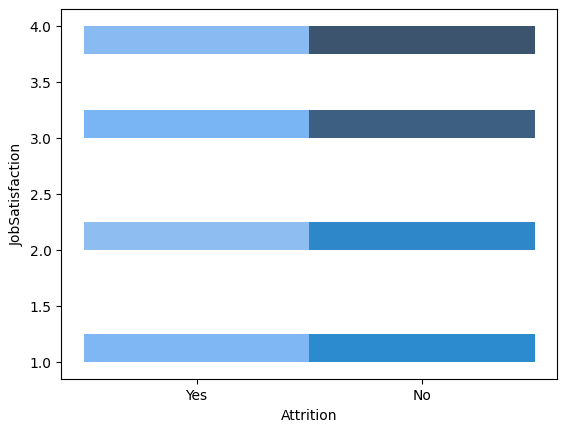

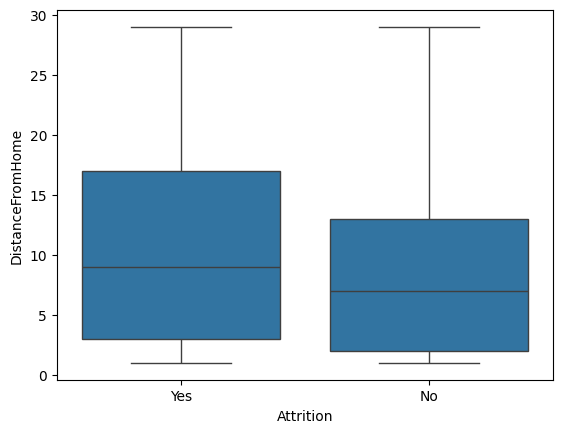

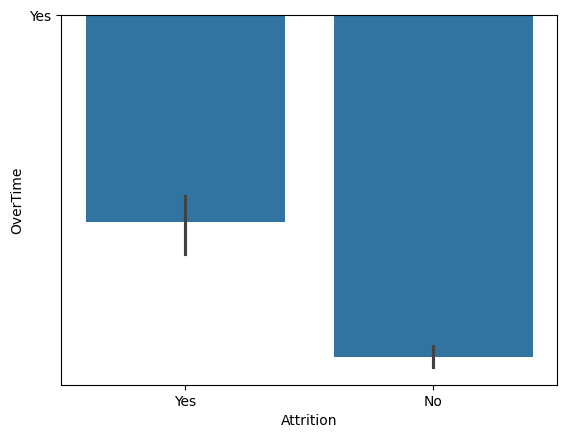

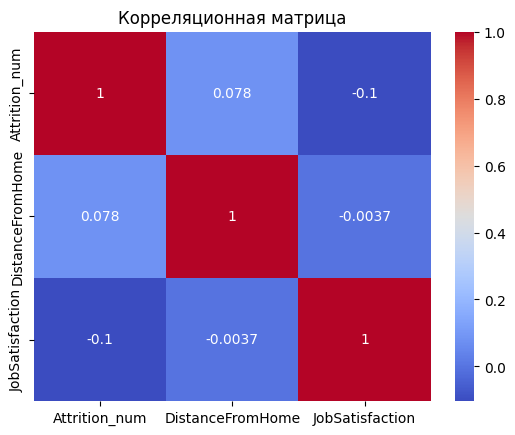

In [104]:
# seaborn.histplot, boxplot, barplot, heatmap
sns.histplot(data=df, x='Attrition', y='JobSatisfaction')
plt.show()
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome')
plt.show()
sns.barplot(data=df, x='Attrition', y='OverTime')
plt.show()

# Преобразование Attrition в числовой формат
df['Attrition_num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
# Корреляционная матрица
corr = df[['Attrition_num', 'DistanceFromHome', 'JobSatisfaction']].corr()
# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

Этап 2: Предобработка данных

1.6 Удаление неинформативных столбцов

In [105]:
# Удаление неинформативных столбцов EmployeeCount, Over18, StandardHours, EmployeeNumber
df = df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1)

1.7 Кодирование категориальных признаков

In [106]:
# LabelEncoder для бинарных (Attrition, OverTime, Gender, BusinessTravel)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [107]:
from sklearn.preprocessing import LabelEncoder

binary_features = ['BusinessTravel']
le = LabelEncoder()
for feature in binary_features:
    df[feature] = le.fit_transform(df[feature])

In [108]:
# OneHotEncoding (или pd.get_dummies) для многокатегорийных (JobRole, Department, MaritalStatus)
df = pd.get_dummies(df, columns=['JobRole', 'Department', 'MaritalStatus', 'EducationField'], drop_first=True).astype(int)

In [109]:
print(df.dtypes)

Age                                  int64
Attrition                            int64
BusinessTravel                       int64
DailyRate                            int64
DistanceFromHome                     int64
Education                            int64
EnvironmentSatisfaction              int64
Gender                               int64
HourlyRate                           int64
JobInvolvement                       int64
JobLevel                             int64
JobSatisfaction                      int64
MonthlyIncome                        int64
MonthlyRate                          int64
NumCompaniesWorked                   int64
OverTime                             int64
PercentSalaryHike                    int64
PerformanceRating                    int64
RelationshipSatisfaction             int64
StockOptionLevel                     int64
TotalWorkingYears                    int64
TrainingTimesLastYear                int64
WorkLifeBalance                      int64
YearsAtComp

1.8 Масштабирование числовых признаков

In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [111]:
# StandardScaler для: MonthlyIncome, DistanceFromHome, Age, YearsAtCompany, YearsInCurrentRole
numeric_features = ['MonthlyIncome', 'DistanceFromHome', 'Age', 'YearsAtCompany', 'YearsInCurrentRole']
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

1.9 Разделение данных

In [112]:
# X — признаки, y — Attrition (преобразованный в 0/1)
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [113]:
# Train/test split: 80% / 20% (train_test_split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Этап 3: Обучение моделей

In [114]:
model_log = LogisticRegression(solver='liblinear', class_weight='balanced')
model_tree = DecisionTreeClassifier(class_weight='balanced')
model_rf = RandomForestClassifier(class_weight='balanced')
model_svc = SVC(class_weight='balanced')
model_nei = KNeighborsClassifier()

In [115]:
# Обучение, предсказание
model_log.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', solver='liblinear')

In [116]:
model_tree.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced')

In [117]:
model_rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [118]:
model_svc.fit(x_train, y_train)

SVC(class_weight='balanced')

In [119]:
model_nei.fit(x_train, y_train)

KNeighborsClassifier()

In [120]:
y_predict_log = model_log.predict(x_test)
y_predict_tree = model_tree.predict(x_test)
y_predict_rf = model_rf.predict(x_test)
y_model_svc = model_svc.predict(x_test)
y_model_nei = model_nei.predict(x_test)

In [121]:
print('accuracy_score:')
print(f'Model Log: {accuracy_score(y_test, y_predict_log)}')
print(f'Model Tree: {accuracy_score(y_test, y_predict_tree)}')
print(f'Model Rf: {accuracy_score(y_test, y_predict_rf)}')
print(f'Model SVC: {accuracy_score(y_test, y_model_svc)}')
print(f'Model Nei: {accuracy_score(y_test, y_model_nei)}')

accuracy_score:
Model Log: 1.0
Model Tree: 1.0
Model Rf: 1.0
Model SVC: 0.6122448979591837
Model Nei: 0.8231292517006803


In [122]:
print('precision_score:')
print(f'Model Log: {precision_score(y_test, y_predict_log)}')
print(f'Model Tree: {precision_score(y_test, y_predict_tree)}')
print(f'Model Rf: {precision_score(y_test, y_predict_rf)}')
print(f'Model SVC: {precision_score(y_test, y_model_svc)}')
print(f'Model Nei: {precision_score(y_test, y_model_nei)}')

precision_score:
Model Log: 1.0
Model Tree: 1.0
Model Rf: 1.0
Model SVC: 0.1134020618556701
Model Nei: 0.15789473684210525


In [123]:
print('recall_score:')
print(f'Model Log: {recall_score(y_test, y_predict_log)}')
print(f'Model Tree: {recall_score(y_test, y_predict_tree)}')
print(f'Model Rf: {recall_score(y_test, y_predict_rf)}')
print(f'Model SVC: {recall_score(y_test, y_model_svc)}')
print(f'Model Nei: {recall_score(y_test, y_model_nei)}')

recall_score:
Model Log: 1.0
Model Tree: 1.0
Model Rf: 1.0
Model SVC: 0.28205128205128205
Model Nei: 0.07692307692307693


In [124]:
print('f1_score:')
print(f'Model Log: {f1_score(y_test, y_predict_log)}')
print(f'Model Tree: {f1_score(y_test, y_predict_tree)}')
print(f'Model Rf: {f1_score(y_test, y_predict_rf)}')
print(f'Model SVC: {f1_score(y_test, y_model_svc)}')
print(f'Model Nei: {f1_score(y_test, y_model_nei)}')

f1_score:
Model Log: 1.0
Model Tree: 1.0
Model Rf: 1.0
Model SVC: 0.16176470588235295
Model Nei: 0.10344827586206896


In [125]:
print('classification_report:')
print(f'Model Log: {classification_report(y_test, y_predict_log)}')
print(f'Model Tree: {classification_report(y_test, y_predict_tree)}')
print(f'Model Rf: {classification_report(y_test, y_predict_rf)}')
print(f'Model SVC: {classification_report(y_test, y_model_svc)}')
print(f'Model Nei: {classification_report(y_test, y_model_nei)}')

classification_report:
Model Log:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       255
           1       1.00      1.00      1.00        39

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294

Model Tree:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       255
           1       1.00      1.00      1.00        39

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294

Model Rf:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       255
           1       1.00      1.00      1.00        39

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg      

In [142]:
joblib.dump(model_log, 'model_log.pkl')
joblib.dump(model_tree, 'model_tree.pkl')
joblib.dump(model_rf, 'model_rf.pkl')
joblib.dump(model_svc, 'model_svc.pkl')
joblib.dump(model_nei, 'model_nei.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [127]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome',
       'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition_num', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'Department_Research & Development',
       'Department_Sales', 'MaritalStatus_Married', 'MaritalStatus_Single',
       'EducationField_Life Sciences', 'EducationField_Mark

In [128]:
# Получаем список столбцов из существующего DataFrame
columns = df.columns.tolist()

# Создаем словарь для группировки
result = {}
for col in columns:
    if '_' in col:
        prefix, suffix = col.split('_', 1)  # Разделяем только на первом '_'
        if prefix not in result:
            result[prefix] = []
        result[prefix].append(suffix)

# Вывод в формате "Префикс_: [значения]"
for prefix, values in result.items():
    print(f"{prefix}_: {values}")

Attrition_: ['num']
JobRole_: ['Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']
Department_: ['Research & Development', 'Sales']
MaritalStatus_: ['Married', 'Single']
EducationField_: ['Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']


In [140]:
df['Attrition_num'].dtype

dtype('int64')

In [129]:
# проверка мин-макс входных данных для schema
value = []
for i in df['YearsWithCurrManager']:
    value.append(i)
print(f'min: {min(value)} --- max: {max(value)}')

min: 0 --- max: 17
